In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset parameters
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

K_PROBES = 4
EPSILON = 0.1
TRAIN_LIMIT = 60000
TEST_LIMIT = 10000
### MNIST has 70,000 images total: 60,000 training and 10,000 test.

# Device setup for CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_dataset = torch.utils.data.Subset(train_dataset, list(range(min(TRAIN_LIMIT, len(train_dataset)))))
test_dataset = torch.utils.data.Subset(test_dataset, list(range(min(TEST_LIMIT, len(test_dataset)))))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

class BaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

        y_hat = self.model(x)
        return y_hat

class FisherClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.intro = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.single_1 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )

        # Classification head uses h_flat (64) + O0/O1/O2 (3) = 67
        self.classifier = nn.Sequential(
            nn.Linear(64 + 3, num_classes),
        )

    def _compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True)[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def _compute_local_fisher(self, x):
        scores = self._compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self._compute_local_fisher(x)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x) * self.epsilon
            x_pos = x + perturbation
            x_neg = x - perturbation

            I_pos = self._compute_local_fisher(x_pos)
            I_neg = self._compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x)
        h_conv = self.single_1(h)
        h_pool = F.adaptive_avg_pool2d(h_conv, 1)
        h_flat = h_pool.view(h_pool.size(0), -1)

        features = torch.cat([h_flat, O0, O1, O2], dim=1)
        y_hat = self.classifier(features)

        return y_hat

def run_experiment(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = FisherClassifier(NUM_CLASSES, K_PROBES, EPSILON)
train_losses_single1, test_accuracies_single1 = run_experiment(model)

model = BaseClassifier(NUM_CLASSES)
train_losses_base, test_accuracies_base = run_experiment(model)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_single1, 'Single1', 'o', 'blue'),
    (train_losses_base, 'Base', 's', 'orange'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_single1, 'Single1', 'o', 'blue'),
    (test_accuracies_base, 'Base', 's', 'orange'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + Single1 Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + Single1 Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_single1_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_single1_training.png'")
plt.show()

Using device: cuda
Train samples: 60000, Test samples: 10000
Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3548
Epoch 0, Batch 100/938: Loss=0.3175
Epoch 0, Batch 200/938: Loss=0.1210
Epoch 0, Batch 300/938: Loss=0.1492
Epoch 0, Batch 400/938: Loss=0.1093
Epoch 0, Batch 500/938: Loss=0.0535
Epoch 0, Batch 600/938: Loss=0.0580
Epoch 0, Batch 700/938: Loss=0.1053
Epoch 0, Batch 800/938: Loss=0.0389
Epoch 0, Batch 900/938: Loss=0.1214
Epoch 0 | Train Loss: 0.1955 | Test Accuracy: 95.65%
Epoch 1, Batch 0/938: Loss=0.1006
Epoch 1, Batch 100/938: Loss=0.1087
Epoch 1, Batch 200/938: Loss=0.0608
Epoch 1, Batch 300/938: Loss=0.0124
Epoch 1, Batch 400/938: Loss=0.1663
Epoch 1, Batch 500/938: Loss=0.0432
Epoch 1, Batch 600/938: Loss=0.0494
Epoch 1, Batch 700/938: Loss=0.0331
Epoch 1, Batch 800/938: Loss=0.0393
Epoch 1, Batch 900/938: Loss=0.0054
Epoch 1 | Train Loss: 0.0606 | Test Accuracy: 96.85%
Epoch 2, Batch 0/938: Loss=0.0222
Epoch 2, Batch 100/938: Loss=0.0156
Epoch 2, Batch 200/9

Train samples: 10000, Test samples: 1000
Starting MNIST Training...
Epoch 0, Batch 0/157: Loss=2.3186
Epoch 0, Batch 100/157: Loss=0.1095
Epoch 0 | Train Loss: 0.4283 | Test Accuracy: 88.10%
Epoch 1, Batch 0/157: Loss=0.0866
Epoch 1, Batch 100/157: Loss=0.1225
Epoch 1 | Train Loss: 0.1262 | Test Accuracy: 90.20%
Epoch 2, Batch 0/157: Loss=0.1406
Epoch 2, Batch 100/157: Loss=0.0337
Epoch 2 | Train Loss: 0.0795 | Test Accuracy: 90.20%
Epoch 3, Batch 0/157: Loss=0.0442
Epoch 3, Batch 100/157: Loss=0.1704
Epoch 3 | Train Loss: 0.0593 | Test Accuracy: 94.10%
Epoch 4, Batch 0/157: Loss=0.0092
Epoch 4, Batch 100/157: Loss=0.1215
Epoch 4 | Train Loss: 0.0482 | Test Accuracy: 75.80%
Final Test Accuracy: 75.80%
Starting MNIST Training...
Epoch 0, Batch 0/157: Loss=2.3102
Epoch 0, Batch 100/157: Loss=0.2441
Epoch 0 | Train Loss: 0.4349 | Test Accuracy: 89.90%
Epoch 1, Batch 0/157: Loss=0.0842
Epoch 1, Batch 100/157: Loss=0.1282
Epoch 1 | Train Loss: 0.1209 | Test Accuracy: 92.80%
Epoch 2, Batch 0

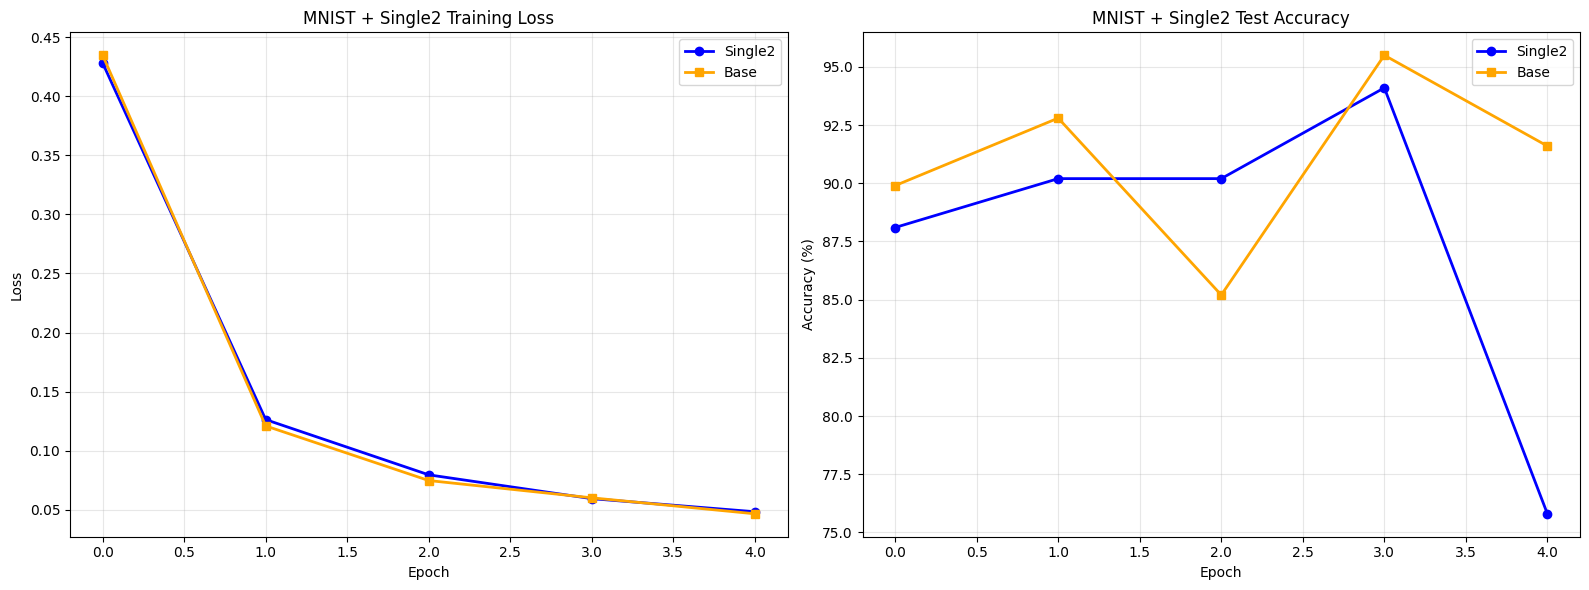

In [ ]:


class BaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

        y_hat = self.model(x)
        return y_hat

class FisherClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.intro = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.single_2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
        )

        # Classification head uses h_flat (128) + O0/O1/O2 (3) = 131
        self.classifier = nn.Sequential(
            nn.Linear(128 + 3, num_classes),
        )

    def _compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True)[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def _compute_local_fisher(self, x):
        scores = self._compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self._compute_local_fisher(x)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x) * self.epsilon
            x_pos = x + perturbation
            x_neg = x - perturbation

            I_pos = self._compute_local_fisher(x_pos)
            I_neg = self._compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x)
        h_conv = self.single_2(h)
        h_pool = F.adaptive_avg_pool2d(h_conv, 1)
        h_flat = h_pool.view(h_pool.size(0), -1)

        features = torch.cat([h_flat, O0, O1, O2], dim=1)
        y_hat = self.classifier(features)

        return y_hat


def run_experiment(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies


# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = FisherClassifier(NUM_CLASSES, K_PROBES, EPSILON)
train_losses_single2, test_accuracies_single2 = run_experiment(model)

model = BaseClassifier(NUM_CLASSES)
train_losses_base, test_accuracies_base = run_experiment(model)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_single2, 'Single2', 'o', 'blue'),
    (train_losses_base, 'Base', 's', 'orange'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_single2, 'Single2', 'o', 'blue'),
    (test_accuracies_base, 'Base', 's', 'orange'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + Single2 Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + Single2 Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_single2_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_single2_training.png'")
plt.show()

Train samples: 10000, Test samples: 1000
Starting MNIST Training...
Epoch 0, Batch 0/157: Loss=2.3370
Epoch 0, Batch 100/157: Loss=0.1650
Epoch 0 | Train Loss: 0.4816 | Test Accuracy: 81.10%
Epoch 1, Batch 0/157: Loss=0.1296
Epoch 1, Batch 100/157: Loss=0.0365
Epoch 1 | Train Loss: 0.1112 | Test Accuracy: 83.80%
Epoch 2, Batch 0/157: Loss=0.0584
Epoch 2, Batch 100/157: Loss=0.0813
Epoch 2 | Train Loss: 0.0766 | Test Accuracy: 91.90%
Epoch 3, Batch 0/157: Loss=0.0414
Epoch 3, Batch 100/157: Loss=0.0070
Epoch 3 | Train Loss: 0.0408 | Test Accuracy: 94.60%
Epoch 4, Batch 0/157: Loss=0.0152
Epoch 4, Batch 100/157: Loss=0.0262
Epoch 4 | Train Loss: 0.0330 | Test Accuracy: 88.80%
Final Test Accuracy: 88.80%
Starting MNIST Training...
Epoch 0, Batch 0/157: Loss=2.3342
Epoch 0, Batch 100/157: Loss=0.1998
Epoch 0 | Train Loss: 0.4539 | Test Accuracy: 90.30%
Epoch 1, Batch 0/157: Loss=0.1087
Epoch 1, Batch 100/157: Loss=0.0739
Epoch 1 | Train Loss: 0.1167 | Test Accuracy: 87.90%
Epoch 2, Batch 0

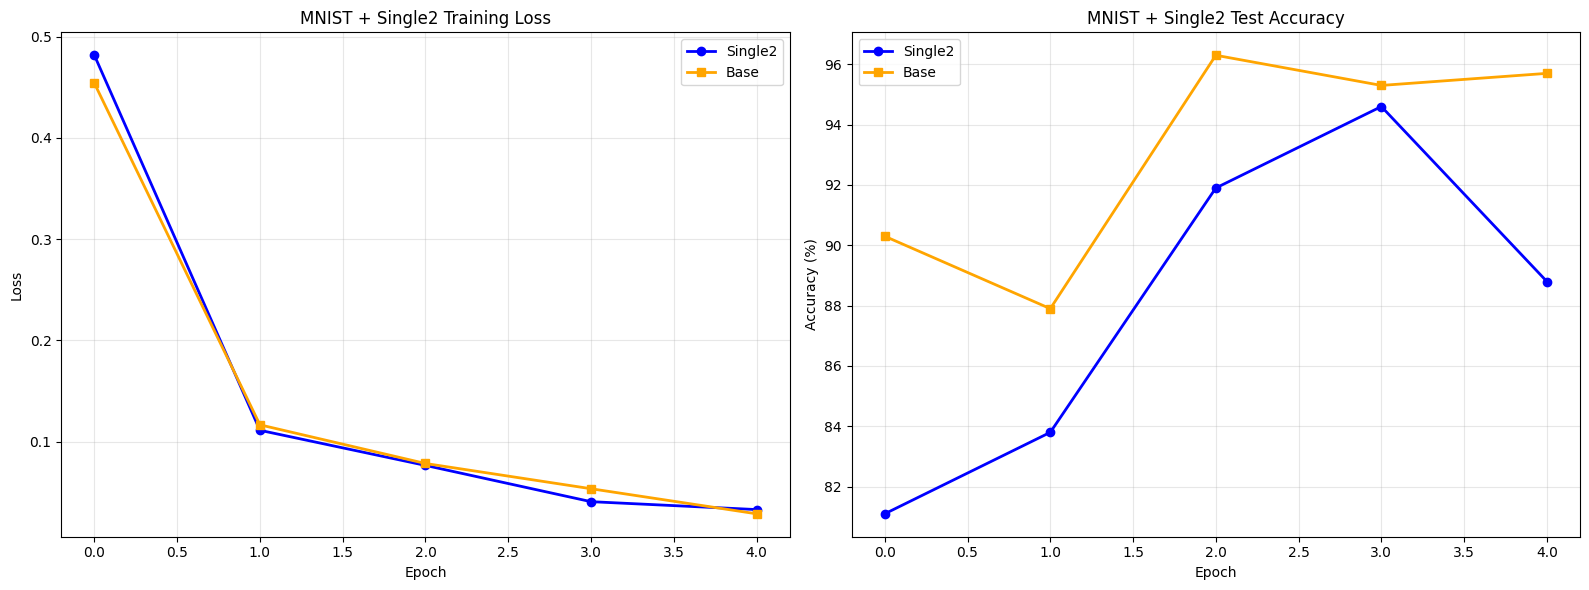

In [ ]:

class BaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

        y_hat = self.model(x)
        return y_hat

class FisherClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.intro = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.ushape1 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )

        # Classification head uses h_flat (64) + O0/O1/O2 (3) = 67
        self.classifier = nn.Sequential(
            nn.Linear(64 + 3, num_classes),
        )

    def _compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True)[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def _compute_local_fisher(self, x):
        scores = self._compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self._compute_local_fisher(x)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x) * self.epsilon
            x_pos = x + perturbation
            x_neg = x - perturbation

            I_pos = self._compute_local_fisher(x_pos)
            I_neg = self._compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x)
        h_conv = self.ushape1(h)
        h_pool = F.adaptive_avg_pool2d(h_conv, 1)
        h_flat = h_pool.view(h_pool.size(0), -1)

        features = torch.cat([h_flat, O0, O1, O2], dim=1)
        y_hat = self.classifier(features)

        return y_hat


def run_experiment(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies


# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = FisherClassifier(NUM_CLASSES, K_PROBES, EPSILON)
train_losses_ushape1, test_accuracies_ushape1 = run_experiment(model)

model = BaseClassifier(NUM_CLASSES)
train_losses_base, test_accuracies_base = run_experiment(model)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_ushape1, 'UShape1', 'o', 'blue'),
    (train_losses_base, 'Base', 's', 'orange'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_ushape1, 'UShape1', 'o', 'blue'),
    (test_accuracies_base, 'Base', 's', 'orange'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + UShape1 Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + UShape1 Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_ushape1_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_ushape1_training.png'")
plt.show()

In [ ]:


class BaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

        y_hat = self.model(x)
        return y_hat

class FisherClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.intro = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.single_3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
        )

        # Classification head uses h_flat (256) + O0/O1/O2 (3) = 259
        self.classifier = nn.Sequential(
            nn.Linear(256 + 3, num_classes),
        )

    def _compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True)[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def _compute_local_fisher(self, x):
        scores = self._compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self._compute_local_fisher(x)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x) * self.epsilon
            x_pos = x + perturbation
            x_neg = x - perturbation

            I_pos = self._compute_local_fisher(x_pos)
            I_neg = self._compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x)
        h_conv = self.single_3(h)
        h_pool = F.adaptive_avg_pool2d(h_conv, 1)
        h_flat = h_pool.view(h_pool.size(0), -1)

        features = torch.cat([h_flat, O0, O1, O2], dim=1)
        y_hat = self.classifier(features)

        return y_hat


def run_experiment(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies


# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = FisherClassifier(NUM_CLASSES, K_PROBES, EPSILON)
train_losses_single3, test_accuracies_single3 = run_experiment(model)

model = BaseClassifier(NUM_CLASSES)
train_losses_base, test_accuracies_base = run_experiment(model)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_single3, 'Single3', 'o', 'blue'),
    (train_losses_base, 'Base', 's', 'orange'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_single3, 'Single3', 'o', 'blue'),
    (test_accuracies_base, 'Base', 's', 'orange'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + Single3 Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + Single3 Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_single3_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_single3_training.png'")
plt.show()

Using device: cuda
Train samples: 10000, Test samples: 1000


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Starting MNIST Training...
Epoch 0, Batch 0/157: Loss=2.3772
Epoch 0, Batch 100/157: Loss=1.7636
Epoch 0 | Train Loss: 1.8351 | Test Accuracy: 27.70%
Epoch 1, Batch 0/157: Loss=1.5789
Epoch 1, Batch 100/157: Loss=1.3662
Epoch 1 | Train Loss: 1.3450 | Test Accuracy: 28.30%
Epoch 2, Batch 0/157: Loss=1.1294
Epoch 2, Batch 100/157: Loss=1.1194
Epoch 2 | Train Loss: 1.1160 | Test Accuracy: 31.30%
Epoch 3, Batch 0/157: Loss=0.8920
Epoch 3, Batch 100/157: Loss=1.0653
Epoch 3 | Train Loss: 0.9699 | Test Accuracy: 36.60%
Epoch 4, Batch 0/157: Loss=0.8211
Epoch 4, Batch 100/157: Loss=0.8760
Epoch 4 | Train Loss: 0.8413 | Test Accuracy: 64.70%
Epoch 5, Batch 0/157: Loss=0.9479
Epoch 5, Batch 100/157: Loss=0.6944
Epoch 5 | Train Loss: 0.7346 | Test Accuracy: 76.80%
Epoch 6, Batch 0/157: Loss=0.7399
Epoch 6, Batch 100/157: Loss=0.7799
Epoch 6 | Train Loss: 0.6708 | Test Accuracy: 63.80%
Epoch 7, Batch 0/157: Loss=0.5958
Epoch 7, Batch 100/157: Loss=0.5007
Epoch 7 | Train Loss: 0.5917 | Test Accura

In [ ]:



class BaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

        y_hat = self.model(x)
        return y_hat

class FisherClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.intro = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.single_3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )

        # Classification head uses h_flat (64) + O0/O1/O2 (3) = 67
        self.classifier = nn.Sequential(
            nn.Linear(64 + 3, num_classes),
        )

    def _compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True)[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def _compute_local_fisher(self, x):
        scores = self._compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self._compute_local_fisher(x)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x) * self.epsilon
            x_pos = x + perturbation
            x_neg = x - perturbation

            I_pos = self._compute_local_fisher(x_pos)
            I_neg = self._compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x)
        h_conv = self.single_3(h)
        h_pool = F.adaptive_avg_pool2d(h_conv, 1)
        h_flat = h_pool.view(h_pool.size(0), -1)

        features = torch.cat([h_flat, O0, O1, O2], dim=1)
        y_hat = self.classifier(features)

        return y_hat


def run_experiment(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies


# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = FisherClassifier(NUM_CLASSES, K_PROBES, EPSILON)
train_losses_single3, test_accuracies_single3 = run_experiment(model)

model = BaseClassifier(NUM_CLASSES)
train_losses_base, test_accuracies_base = run_experiment(model)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_single3, 'Single3', 'o', 'blue'),
    (train_losses_base, 'Base', 's', 'orange'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_single3, 'Single3', 'o', 'blue'),
    (test_accuracies_base, 'Base', 's', 'orange'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + Single3 Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + Single3 Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_single3_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_single3_training.png'")
plt.show()


In [ ]:


class BaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

        y_hat = self.model(x)
        return y_hat

class FisherClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.intro = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.single_4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
        )

        # Classification head uses h_flat (512) + O0/O1/O2 (3) = 515
        self.classifier = nn.Sequential(
            nn.Linear(512 + 3, num_classes),
        )

    def _compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True)[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def _compute_local_fisher(self, x):
        scores = self._compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self._compute_local_fisher(x)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x) * self.epsilon
            x_pos = x + perturbation
            x_neg = x - perturbation

            I_pos = self._compute_local_fisher(x_pos)
            I_neg = self._compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x)
        h_conv = self.single_4(h)
        h_pool = F.adaptive_avg_pool2d(h_conv, 1)
        h_flat = h_pool.view(h_pool.size(0), -1)

        features = torch.cat([h_flat, O0, O1, O2], dim=1)
        y_hat = self.classifier(features)

        return y_hat


def run_experiment(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies


# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = FisherClassifier(NUM_CLASSES, K_PROBES, EPSILON)
train_losses_single4, test_accuracies_single4 = run_experiment(model)

model = BaseClassifier(NUM_CLASSES)
train_losses_base, test_accuracies_base = run_experiment(model)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_single4, 'Single4', 'o', 'blue'),
    (train_losses_base, 'Base', 's', 'orange'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_single4, 'Single4', 'o', 'blue'),
    (test_accuracies_base, 'Base', 's', 'orange'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + Single4 Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + Single4 Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_single4_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_single4_training.png'")
plt.show()

In [ ]:

class BaseClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

        y_hat = self.model(x)
        return y_hat

class FisherClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.intro = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.ushape2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
        )

        # Classification head uses h_flat (64) + O0/O1/O2 (3) = 67
        self.classifier = nn.Sequential(
            nn.Linear(64 + 3, num_classes),
        )

    def _compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True)[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def _compute_local_fisher(self, x):
        scores = self._compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self._compute_local_fisher(x)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x) * self.epsilon
            x_pos = x + perturbation
            x_neg = x - perturbation

            I_pos = self._compute_local_fisher(x_pos)
            I_neg = self._compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x)
        h_conv = self.ushape2(h)
        h_pool = F.adaptive_avg_pool2d(h_conv, 1)
        h_flat = h_pool.view(h_pool.size(0), -1)

        features = torch.cat([h_flat, O0, O1, O2], dim=1)
        y_hat = self.classifier(features)

        return y_hat


def run_experiment(model):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies


# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = FisherClassifier(NUM_CLASSES, K_PROBES, EPSILON)
train_losses_ushape2, test_accuracies_ushape2 = run_experiment(model)

model = BaseClassifier(NUM_CLASSES)
train_losses_base, test_accuracies_base = run_experiment(model)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_ushape2, 'UShape2', 'o', 'blue'),
    (train_losses_base, 'Base', 's', 'orange'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_ushape2, 'UShape2', 'o', 'blue'),
    (test_accuracies_base, 'Base', 's', 'orange'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + UShape2 Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + UShape2 Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_ushape2_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_ushape2_training.png'")
plt.show()

Using device: cuda
Train samples: 60000, Test samples: 10000
Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3648
Epoch 0, Batch 100/938: Loss=2.3011
Epoch 0, Batch 200/938: Loss=2.2998
Epoch 0, Batch 300/938: Loss=2.2952
Epoch 0, Batch 400/938: Loss=2.3024
Epoch 0, Batch 500/938: Loss=2.3011
Epoch 0, Batch 600/938: Loss=2.2990
Epoch 0, Batch 700/938: Loss=2.3019
Epoch 0, Batch 800/938: Loss=2.2960
Epoch 0, Batch 900/938: Loss=2.3059
Epoch 0 | Train Loss: 2.3032 | Test Accuracy: 11.35%
Epoch 1, Batch 0/938: Loss=2.2952
Epoch 1, Batch 100/938: Loss=2.2953
Epoch 1, Batch 200/938: Loss=2.3049


KeyboardInterrupt: 

In [ ]:
import pandas as pd

rows = []

g = globals()
loss_keys = sorted([k for k in g.keys() if k.startswith('train_losses_')])

for loss_key in loss_keys:
    suffix = loss_key.replace('train_losses_', '', 1)
    acc_key = f'test_accuracies_{suffix}'

    losses = g.get(loss_key)
    accuracies = g.get(acc_key)

    if losses is None or accuracies is None:
        continue

    n_epochs = min(len(losses), len(accuracies))
    for epoch in range(n_epochs):
        rows.append({
            'experiment': suffix,
            'epoch': epoch,
            'train_loss': float(losses[epoch]),
            'test_accuracy': float(accuracies[epoch])
        })

if not rows:
    raise RuntimeError(
        "No training outputs found. Run Cells 1–8 first so train_losses_* and test_accuracies_* variables exist."
    )

output_df = pd.DataFrame(rows).sort_values(['experiment', 'epoch']).reset_index(drop=True)
output_path = 'shallow_output.csv'
output_df.to_csv(output_path, index=False)

print(f"Saved {len(output_df)} rows to {output_path}")
print(output_df.head())

Saved 40 rows to test1_copycopy_output.csv
              experiment  epoch  train_loss  test_accuracy
0  resnet101_fisher_adam      0    1.835122           27.7
1  resnet101_fisher_adam      1    1.345013           28.3
2  resnet101_fisher_adam      2    1.116025           31.3
3  resnet101_fisher_adam      3    0.969885           36.6
4  resnet101_fisher_adam      4    0.841296           64.7
